### XGBoost Model made using Python
Relevant Statistics: Made via XGBoost w 100 estimators

Accuracy: 0.7540  

Precision: 0.7331

Recall: 0.7896

F1 Score: 0.7603

ROC AUC: 0.7544

In [1]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


In [3]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
model = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=20)
model.fit(X_train_scaled, y_train.ravel())

c:\Users\bahra\anaconda3\envs\researchenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [5]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

Accuracy: 0.7540
Precision: 0.7331
Recall: 0.7896
F1 Score: 0.7603
ROC AUC: 0.7544


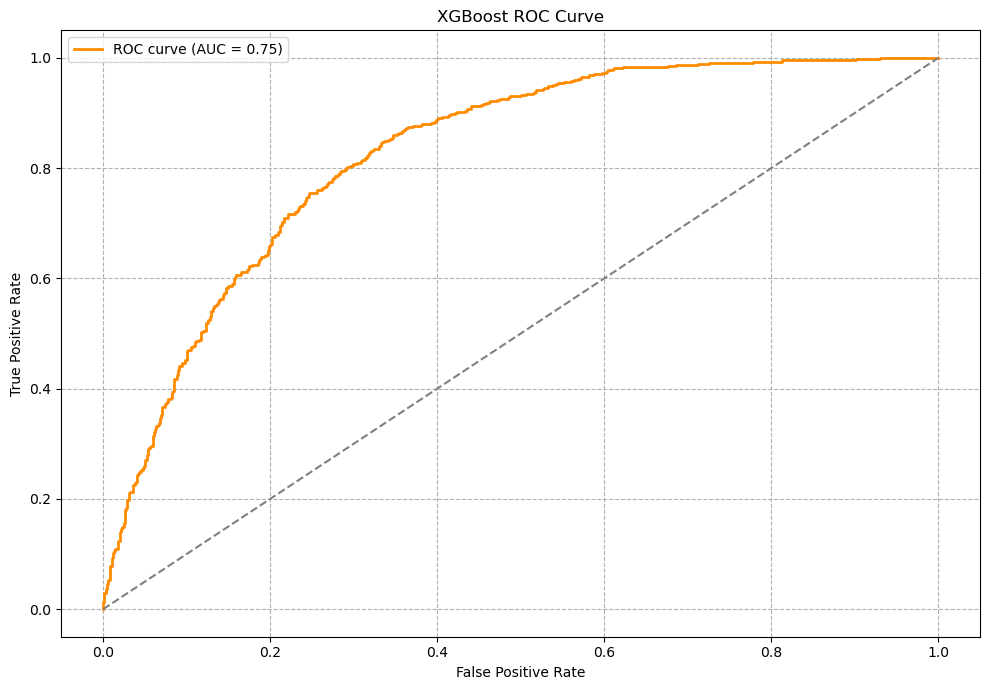

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plots

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(10,7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid(True, ls='--')
plt.tight_layout()
plt.show()